In [260]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)



## Preprocessing

In [261]:
# Load the CSV file
file_path = "EGX30_2000-2025.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())
    

       Date      Price       Open       High        Low     Vol. Change %
0  2/6/2025  30,011.84  29,735.59  30,011.84  29,735.59   83.50M    0.93%
1  2/5/2025  29,735.59  29,668.47  29,772.63  29,596.50  103.71M    0.23%
2  2/4/2025  29,668.47  29,754.77  29,937.39  29,668.47  135.05M   -0.29%
3  2/3/2025  29,754.77  29,917.96  30,001.23  29,698.79  152.06M   -0.55%
4  2/2/2025  29,917.96  30,010.62  30,198.22  29,917.96  103.16M   -0.31%


**Date:** The trading date of the EGX30 index (formatted as MM/DD/YYYY).

**Price:** The closing price of the EGX30 index on that particular day.

**Open:** The opening price of the EGX30 index at the start of the trading session.

**High:** The highest price the EGX30 index reached during the trading session.

**Low:** The lowest price the EGX30 index reached during the trading session.

**Vol. (Volume):** The total number of shares traded during that day.

**Change %:** The percentage change in the EGX30 index compared to the previous trading day's closing price.

In [262]:
# # Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])


In [263]:
print(df.head())


        Date      Price       Open       High        Low     Vol. Change %
0 2025-02-06  30,011.84  29,735.59  30,011.84  29,735.59   83.50M    0.93%
1 2025-02-05  29,735.59  29,668.47  29,772.63  29,596.50  103.71M    0.23%
2 2025-02-04  29,668.47  29,754.77  29,937.39  29,668.47  135.05M   -0.29%
3 2025-02-03  29,754.77  29,917.96  30,001.23  29,698.79  152.06M   -0.55%
4 2025-02-02  29,917.96  30,010.62  30,198.22  29,917.96  103.16M   -0.31%


In [264]:
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6106 entries, 0 to 6105
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      6106 non-null   datetime64[ns]
 1   Price     6106 non-null   object        
 2   Open      6106 non-null   object        
 3   High      6106 non-null   object        
 4   Low       6106 non-null   object        
 5   Vol.      3906 non-null   object        
 6   Change %  6106 non-null   object        
dtypes: datetime64[ns](1), object(6)
memory usage: 334.0+ KB
None


In [265]:
print(df.describe())

                                Date
count                           6106
mean   2012-07-24 03:15:30.363576832
min              2000-02-06 00:00:00
25%              2006-04-06 18:00:00
50%              2012-07-29 12:00:00
75%              2018-10-29 18:00:00
max              2025-02-06 00:00:00


In [266]:
# Convert numerical columns by removing commas and converting to float
cols_to_convert = ['Price', 'Open', 'High', 'Low']
df[cols_to_convert] = df[cols_to_convert].replace(',', '', regex=True).astype(float)

In [267]:
# Convert Change % column (remove '%' and convert to decimal)
df['Change %'] = df['Change %'].str.replace('%', '', regex=True).astype(float) / 100

In [268]:

def convert_vol(value):
    if isinstance(value, str):  # Ensure value is a string
        if 'M' in value:
            return float(value.replace('M', '')) * 1_000_000
        elif 'B' in value:
            return float(value.replace('B', '')) * 1_000_000_000
        else:
            return float(value)  # Convert numbers stored as strings
    return value  # Return original if already float or NaN

df['Vol.'] = df['Vol.'].apply(convert_vol)



In [269]:
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,2025-02-06,30011.84,29735.59,30011.84,29735.59,83500000.0,0.0093
1,2025-02-05,29735.59,29668.47,29772.63,29596.50,103710000.0,0.0023
2,2025-02-04,29668.47,29754.77,29937.39,29668.47,135050000.0,-0.0029
3,2025-02-03,29754.77,29917.96,30001.23,29698.79,152060000.0,-0.0055
4,2025-02-02,29917.96,30010.62,30198.22,29917.96,103160000.0,-0.0031


In [270]:
# Check how many missing values exist in the Volume column initially.
initial_missing = df['Vol.'].isnull().sum()
print("\nMissing 'Vol.' values before imputation:", initial_missing)


Missing 'Vol.' values before imputation: 2200


In [271]:
print(df.isnull().sum())

Date           0
Price          0
Open           0
High           0
Low            0
Vol.        2200
Change %       0
dtype: int64


In [272]:
df.dropna(inplace=True)

In [273]:
print(df.isnull().sum())

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64


In [274]:
print(df.dtypes)

Date        datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %           float64
dtype: object


In [275]:
df

,Date,Price,Open,High,Low,Vol.,Change %
0,2025-02-06,30011.84,29735.59,30011.84,29735.59,83500000.0,0.0093
1,2025-02-05,29735.59,29668.47,29772.63,29596.50,103710000.0,0.0023
2,2025-02-04,29668.47,29754.77,29937.39,29668.47,135050000.0,-0.0029
3,2025-02-03,29754.77,29917.96,30001.23,29698.79,152060000.0,-0.0055
4,2025-02-02,29917.96,30010.62,30198.22,29917.96,103160000.0,-0.0031
...,...,...,...,...,...,...,...
3928,2008-12-03,3979.71,4014.26,4085.91,3979.71,40440000.0,0.0107
3929,2008-12-02,3937.66,3886.00,3937.66,3829.44,35650000.0,-0.0211
3930,2008-12-01,4022.58,4185.59,4185.59,4022.58,36480000.0,-0.0436
3931,2008-11-30,4205.86,4100.29,4228.08,4100.29,43360000.0,0.0401


Detect Outliers

In [276]:
# Function to detect outliers using the IQR method
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)  # First quartile (25%)
    Q3 = df[column].quantile(0.75)  # Third quartile (75%)
    IQR = Q3 - Q1  # Interquartile Range
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Detect outliers in the "Price" column
outliers_price = detect_outliers_iqr(df, 'Price')
print("Outliers in Price column:\n", outliers_price)

# Detect outliers in Volume column
outliers_vol = detect_outliers_iqr(df, 'Vol.')
print("Outliers in Volume column:\n", outliers_vol)

Outliers in Price column:
           Date     Price      Open      High       Low         Vol.  Change %
0   2025-02-06  30011.84  29735.59  30011.84  29735.59   83500000.0    0.0093
1   2025-02-05  29735.59  29668.47  29772.63  29596.50  103710000.0    0.0023
2   2025-02-04  29668.47  29754.77  29937.39  29668.47  135050000.0   -0.0029
3   2025-02-03  29754.77  29917.96  30001.23  29698.79  152060000.0   -0.0055
4   2025-02-02  29917.96  30010.62  30198.22  29917.96  103160000.0   -0.0031
..         ...       ...       ...       ...       ...          ...       ...
293 2023-11-23  25519.49  25029.57  25563.41  25029.57  329530000.0    0.0196
294 2023-11-22  25029.57  24774.04  25098.40  24774.04  227890000.0    0.0103
295 2023-11-21  24774.04  24760.02  24774.04  24517.90  216010000.0    0.0006
296 2023-11-20  24760.02  24899.59  25337.90  24726.00  242590000.0   -0.0056
297 2023-11-19  24899.59  24383.27  24958.79  24383.27  270690000.0    0.0212

[282 rows x 7 columns]
Outliers in V

In [277]:
# # Calculate Q1, Q3, and IQR
# Q1 = df['Price'].quantile(0.25)
# Q3 = df['Price'].quantile(0.75)
# IQR = Q3 - Q1

# # Define lower and upper bounds for outliers
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# # Identify outliers
# outliers_iqr = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]
# print("Outliers detected using IQR:")
# print(outliers_iqr)

Outliers

In [278]:
# Function to remove outliers using IQR method
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)  # 25th percentile
    Q3 = df[column].quantile(0.75)  # 75th percentile
    IQR = Q3 - Q1  # Interquartile range
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]  # Keep only in-range values

# Remove outliers from "Vol."
data_cleaned = remove_outliers_iqr(df, 'Vol.')

# Print before & after removing outliers
print(f"Original data shape: {df.shape}")
print(f"Cleaned data shape: {data_cleaned.shape}")

# # Save the cleaned dataset (optional)
# data_cleaned.to_csv("cleaned_dataset.csv", index=False)


Original data shape: (3906, 7)
Cleaned data shape: (3722, 7)


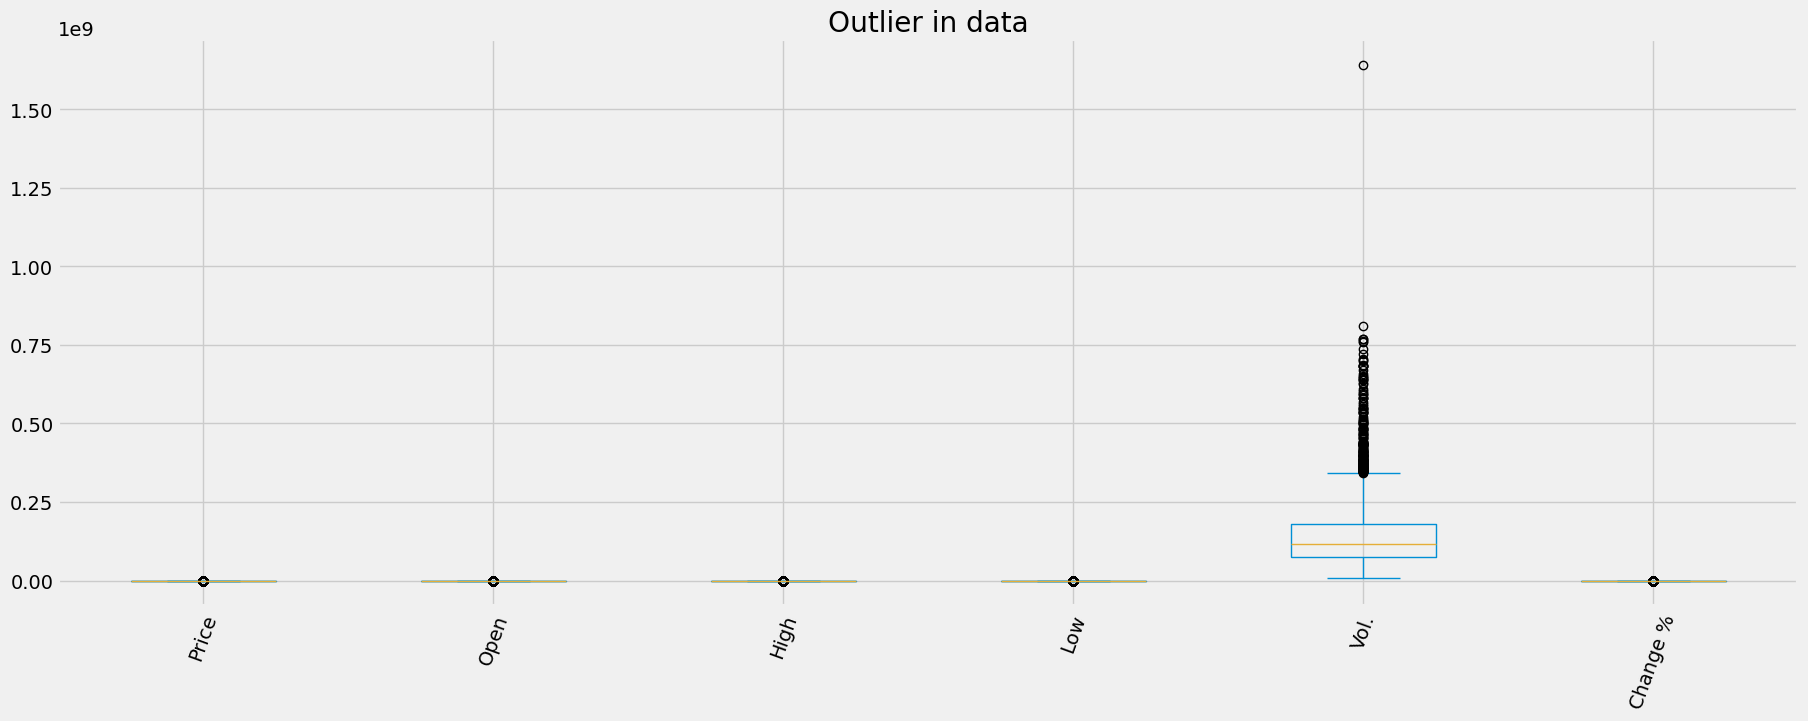

In [279]:
import matplotlib.pyplot as plt
# outlier
plt.style.use('fivethirtyeight')
outlier= df.plot(kind='box',figsize=(20,7));
plt.xticks(rotation=70);
plt.title('Outlier in data');


In [280]:
# import pandas as pd
# from scipy.stats import zscore

# # Calculate Z-scores for the 'Price' column
# df['Z-Score'] = zscore(df['Vol.'])

# # Identify outliers (Z-Score > 3 or Z-Score < -3)
# outliers_zscore = df[(df['Z-Score'] > 3) | (df['Z-Score'] < -3)]
# print("Outliers detected using Z-Score:")
# print(outliers_zscore)

In [281]:
# Check for duplicates in the entire DataFrame
print("Are there any duplicate rows?")
print(df.duplicated().any())  # Returns True if there are duplicates

# Find duplicate rows
print("\nDuplicate Rows:")
print(df[df.duplicated()])

# Count the number of duplicate rows
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

# Check for duplicates based on a specific column (e.g., 'ID')
print("\nDuplicate Date:")
print(df[df.duplicated(subset=['Date'])])

Are there any duplicate rows?
False

Duplicate Rows:
Empty DataFrame
Columns: [Date, Price, Open, High, Low, Vol., Change %]
Index: []

Number of Duplicate Rows:
0

Duplicate Date:
Empty DataFrame
Columns: [Date, Price, Open, High, Low, Vol., Change %]
Index: []


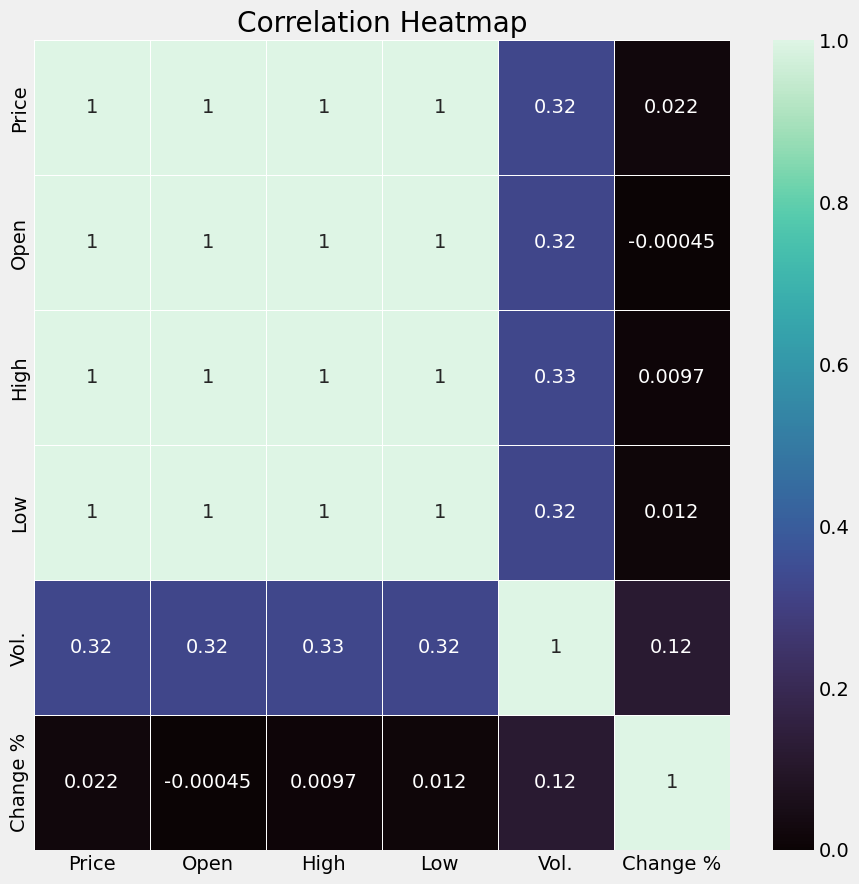

In [282]:
import seaborn as sns
numerical_features= df.select_dtypes(include=['int64', 'float64']).copy()
plt.figure(figsize=(10,10))
Correlation_df = df.select_dtypes(include=['int64', 'float64','bool']).copy()
sns.heatmap(Correlation_df.corr(), annot= True, linewidths= 0.5,cmap='mako')
plt.title('Correlation Heatmap')
plt.show()

In [283]:
df

,Date,Price,Open,High,Low,Vol.,Change %
0,2025-02-06,30011.84,29735.59,30011.84,29735.59,83500000.0,0.0093
1,2025-02-05,29735.59,29668.47,29772.63,29596.50,103710000.0,0.0023
2,2025-02-04,29668.47,29754.77,29937.39,29668.47,135050000.0,-0.0029
3,2025-02-03,29754.77,29917.96,30001.23,29698.79,152060000.0,-0.0055
4,2025-02-02,29917.96,30010.62,30198.22,29917.96,103160000.0,-0.0031
...,...,...,...,...,...,...,...
3928,2008-12-03,3979.71,4014.26,4085.91,3979.71,40440000.0,0.0107
3929,2008-12-02,3937.66,3886.00,3937.66,3829.44,35650000.0,-0.0211
3930,2008-12-01,4022.58,4185.59,4185.59,4022.58,36480000.0,-0.0436
3931,2008-11-30,4205.86,4100.29,4228.08,4100.29,43360000.0,0.0401


Feature Engineering

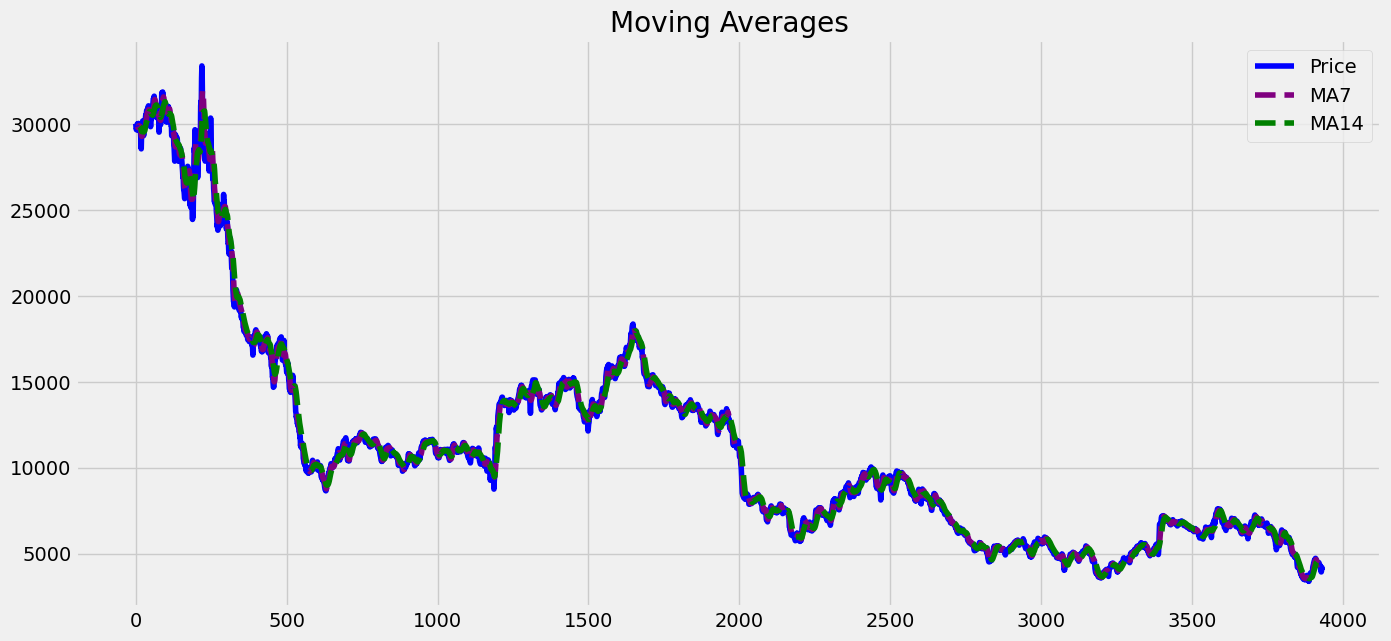

In [284]:
# Moving Average 
# Assuming df has a column 'Close' representing stock prices
df['MA7'] = df['Price'].rolling(window=7).mean()
df['MA14'] = df['Price'].rolling(window=14).mean()
# df['MA10'] = df['Price'].rolling(window=10).mean()  # 10-day moving average
# df['MA20'] = df['Price'].rolling(window=20).mean()


# Plot Moving Averages with Price
plt.figure(figsize=(15,7))
plt.plot(df['Price'], label='Price', color='blue')
plt.plot(df['MA7'], label='MA7', linestyle='dashed', color='purple')
plt.plot(df['MA14'], label='MA14', linestyle='dashed', color='green')
# plt.plot(df['MA20'], label='MA20', linestyle='dashed', color='red')
plt.legend()
plt.title('Moving Averages')
plt.show()


In [285]:
df

,Date,Price,Open,High,Low,Vol.,Change %,MA7,MA14
0,2025-02-06,30011.84,29735.59,30011.84,29735.59,83500000.0,0.0093,NaN,NaN
1,2025-02-05,29735.59,29668.47,29772.63,29596.50,103710000.0,0.0023,NaN,NaN
2,2025-02-04,29668.47,29754.77,29937.39,29668.47,135050000.0,-0.0029,NaN,NaN
3,2025-02-03,29754.77,29917.96,30001.23,29698.79,152060000.0,-0.0055,NaN,NaN
4,2025-02-02,29917.96,30010.62,30198.22,29917.96,103160000.0,-0.0031,NaN,NaN
...,...,...,...,...,...,...,...,...,...
3928,2008-12-03,3979.71,4014.26,4085.91,3979.71,40440000.0,0.0107,4237.780000,4306.652143
3929,2008-12-02,3937.66,3886.00,3937.66,3829.44,35650000.0,-0.0211,4166.735714,4276.630714
3930,2008-12-01,4022.58,4185.59,4185.59,4022.58,36480000.0,-0.0436,4117.578571,4254.537857
3931,2008-11-30,4205.86,4100.29,4228.08,4100.29,43360000.0,0.0401,4103.840000,4246.080000


In [286]:
df = df.iloc[14:].reset_index(drop=True)
df

,Date,Price,Open,High,Low,Vol.,Change %,MA7,MA14
0,2025-01-19,29728.61,29605.12,29840.53,29605.12,90300000.0,0.0042,29846.911429,29825.285714
1,2025-01-16,29605.12,29389.93,29730.63,29389.93,90700000.0,0.0073,29827.340000,29815.966429
2,2025-01-15,29389.93,28967.09,29389.93,28967.09,128560000.0,0.0146,29735.208571,29796.070714
3,2025-01-14,28967.09,28556.28,29097.25,28349.98,105460000.0,0.0144,29587.980000,29739.807857
4,2025-01-13,28556.28,29277.45,29587.41,28556.28,93270000.0,-0.0246,29384.714286,29642.545000
...,...,...,...,...,...,...,...,...,...
3887,2008-12-03,3979.71,4014.26,4085.91,3979.71,40440000.0,0.0107,4237.780000,4306.652143
3888,2008-12-02,3937.66,3886.00,3937.66,3829.44,35650000.0,-0.0211,4166.735714,4276.630714
3889,2008-12-01,4022.58,4185.59,4185.59,4022.58,36480000.0,-0.0436,4117.578571,4254.537857
3890,2008-11-30,4205.86,4100.29,4228.08,4100.29,43360000.0,0.0401,4103.840000,4246.080000


In [287]:
import pandas as pd

def compute_rsi(df, column='Price', window=14):
    delta = df[column].diff(1)  # Calculate the price change

    gain = delta.where(delta > 0, 0)  # Keep gains, replace losses with 0
    loss = -delta.where(delta < 0, 0)  # Keep losses, replace gains with 0

    avg_gain = gain.rolling(window=window, min_periods=window).mean()  # Average gain over 14 days
    avg_loss = loss.rolling(window=window, min_periods=window).mean()  # Average loss over 14 days

    rs = avg_gain / avg_loss  # Relative Strength (RS)
    rsi = 100 - (100 / (1 + rs))  # RSI Calculation

    df['RSI'] = rsi  # Add RSI to DataFrame
    return df

# Apply RSI function to DataFrame
df = compute_rsi(df)

# Drop NaN values from the first 14 rows where RSI cannot be computed
df.dropna(inplace=True)

In [288]:
import ta  # Technical analysis library
#  1. Daily Range (High - Low)
df["Daily Range"] = df["High"] - df["Low"]

# 2. Price Change (Close - Open)
df["Price Change"] = df["Price"] - df["Open"]

# 3. Volatility (High - Low) / Open
df["Volatility"] = (df["High"] - df["Low"]) / df["Open"]

# # 4. Cumulative Returns (Price Change over multiple days)
# df["Cumulative Return"] = df["Price"].pct_change().fillna(0).cumsum()

# 5. Moving Averages
# df["MA50"] = df["Price"].rolling(window=50).mean()
# df["MA100"] = df["Price"].rolling(window=100).mean()

# 1. Extract Quarter of the Year
df["Quarter"] = df["Date"].dt.quarter


# 6. Average True Range (ATR)
df["ATR"] = ta.volatility.AverageTrueRange(df["High"], df["Low"], df["Price"], window=14).average_true_range()

# 7. MACD (Moving Average Convergence Divergence)
df["MACD"] = ta.trend.MACD(df["Price"]).macd()

# 8. Bollinger Bands
bb = ta.volatility.BollingerBands(df["Price"], window=20)
df["BB_High"] = bb.bollinger_hband()
df["BB_Low"] = bb.bollinger_lband()

# 9. Stochastic Oscillator
stoch = ta.momentum.StochasticOscillator(df["High"], df["Low"], df["Price"], window=14)
df["Stoch"] = stoch.stoch()


# Drop NaN values from the first 14 rows where RSI cannot be computed
df.dropna(inplace=True)

# Display Processed Data
print(df.head())

         Date     Price      Open      High       Low         Vol.  Change %  \
38 2024-11-24  30397.22  30631.80  30779.96  30397.22   63370000.0   -0.0077   
39 2024-11-21  30631.80  30587.99  30795.30  30587.99   72730000.0    0.0014   
40 2024-11-20  30587.99  30688.30  30783.53  30503.57   70140000.0   -0.0033   
41 2024-11-19  30688.30  30864.34  30898.74  30688.30   80670000.0   -0.0057   
42 2024-11-18  30864.34  31252.07  31359.65  30864.34  105240000.0   -0.0124   

             MA7          MA14        RSI  Daily Range  Price Change  \
38  30294.671429  30556.167143  41.756621       382.74       -234.58   
39  30309.882857  30548.491429  47.927099       207.31         43.81   
40  30322.862857  30546.360000  49.406618       279.96       -100.31   
41  30386.601429  30523.730000  42.888185       210.44       -176.04   
42  30532.072857  30509.717857  45.822740       495.31       -387.73   

    Volatility  Quarter         ATR        MACD       BB_High        BB_Low  \
38    0

In [289]:
df

,Date,Price,Open,High,Low,Vol.,Change %,MA7,MA14,RSI,Daily Range,Price Change,Volatility,Quarter,ATR,MACD,BB_High,BB_Low,Stoch
38,2024-11-24,30397.22,30631.80,30779.96,30397.22,63370000.0,-0.0077,30294.671429,30556.167143,41.756621,382.74,-234.58,0.012495,4,396.273894,56.024606,31153.607422,30025.220578,43.126991
39,2024-11-21,30631.80,30587.99,30795.30,30587.99,72730000.0,0.0014,30309.882857,30548.491429,47.927099,207.31,43.81,0.006777,4,396.402902,69.764822,31158.385392,30030.951608,59.094808
40,2024-11-20,30587.99,30688.30,30783.53,30503.57,70140000.0,-0.0033,30322.862857,30546.360000,49.406618,279.96,-100.31,0.009123,4,388.085551,76.240094,31161.084834,30036.744166,56.112669
41,2024-11-19,30688.30,30864.34,30898.74,30688.30,80670000.0,-0.0057,30386.601429,30523.730000,42.888185,210.44,-176.04,0.006818,4,382.561583,88.446416,31166.769330,30039.725670,62.940752
42,2024-11-18,30864.34,31252.07,31359.65,30864.34,105240000.0,-0.0124,30532.072857,30509.717857,45.822740,495.31,-387.73,0.015849,4,403.189327,111.044915,31175.220583,30037.765417,68.965539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3887,2008-12-03,3979.71,4014.26,4085.91,3979.71,40440000.0,0.0107,4237.780000,4306.652143,26.503907,106.20,-34.55,0.026456,4,147.206246,-13.406851,4776.599856,4011.599144,1.894445
3888,2008-12-02,3937.66,3886.00,3937.66,3829.44,35650000.0,-0.0211,4166.735714,4276.630714,24.571041,108.22,51.66,0.027849,4,147.425085,-38.026962,4757.617732,3953.162268,15.745901
3889,2008-12-01,4022.58,4185.59,4185.59,4022.58,36480000.0,-0.0436,4117.578571,4254.537857,32.530556,163.01,-163.01,0.038946,4,154.604008,-50.108622,4708.102436,3931.807564,28.101675
3890,2008-11-30,4205.86,4100.29,4228.08,4100.29,43360000.0,0.0401,4103.840000,4246.080000,44.419519,127.79,105.57,0.031166,4,158.239436,-44.382646,4641.471304,3947.986696,54.768729


In [290]:
# import pandas as pd

# df['Daily_Change'] = df['Price'].diff()  # الفرق بين إغلاق اليوم وإغلاق الأمس

# # نفترض أن لديك DataFrame يحتوي على أسعار الإغلاق
# df['Daily_Return'] = df['Price'].pct_change() * 100  # التغير كنسبة مئوية

In [291]:
df

,Date,Price,Open,High,Low,Vol.,Change %,MA7,MA14,RSI,Daily Range,Price Change,Volatility,Quarter,ATR,MACD,BB_High,BB_Low,Stoch
38,2024-11-24,30397.22,30631.80,30779.96,30397.22,63370000.0,-0.0077,30294.671429,30556.167143,41.756621,382.74,-234.58,0.012495,4,396.273894,56.024606,31153.607422,30025.220578,43.126991
39,2024-11-21,30631.80,30587.99,30795.30,30587.99,72730000.0,0.0014,30309.882857,30548.491429,47.927099,207.31,43.81,0.006777,4,396.402902,69.764822,31158.385392,30030.951608,59.094808
40,2024-11-20,30587.99,30688.30,30783.53,30503.57,70140000.0,-0.0033,30322.862857,30546.360000,49.406618,279.96,-100.31,0.009123,4,388.085551,76.240094,31161.084834,30036.744166,56.112669
41,2024-11-19,30688.30,30864.34,30898.74,30688.30,80670000.0,-0.0057,30386.601429,30523.730000,42.888185,210.44,-176.04,0.006818,4,382.561583,88.446416,31166.769330,30039.725670,62.940752
42,2024-11-18,30864.34,31252.07,31359.65,30864.34,105240000.0,-0.0124,30532.072857,30509.717857,45.822740,495.31,-387.73,0.015849,4,403.189327,111.044915,31175.220583,30037.765417,68.965539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3887,2008-12-03,3979.71,4014.26,4085.91,3979.71,40440000.0,0.0107,4237.780000,4306.652143,26.503907,106.20,-34.55,0.026456,4,147.206246,-13.406851,4776.599856,4011.599144,1.894445
3888,2008-12-02,3937.66,3886.00,3937.66,3829.44,35650000.0,-0.0211,4166.735714,4276.630714,24.571041,108.22,51.66,0.027849,4,147.425085,-38.026962,4757.617732,3953.162268,15.745901
3889,2008-12-01,4022.58,4185.59,4185.59,4022.58,36480000.0,-0.0436,4117.578571,4254.537857,32.530556,163.01,-163.01,0.038946,4,154.604008,-50.108622,4708.102436,3931.807564,28.101675
3890,2008-11-30,4205.86,4100.29,4228.08,4100.29,43360000.0,0.0401,4103.840000,4246.080000,44.419519,127.79,105.57,0.031166,4,158.239436,-44.382646,4641.471304,3947.986696,54.768729
